In [1]:
!pip install ultralytics fiftyone opencv-python


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.8 MB/s eta 0:

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz


/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [3]:
dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=["Helmet", "Person","Motorcycle"],
    max_samples=5000   # increase if you want better accuracy
)


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [28.4s elapsed, 0s remaining, 159.3Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [28.4s elapsed, 0s remaining, 159.3Mb/s]      


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/train/metadata/classes.csv'


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'train'


 100% |███████████████| 5000/5000 [50.4s elapsed, 0s remaining, 99.0 samples/s]       


INFO:eta.core.utils: 100% |███████████████| 5000/5000 [50.4s elapsed, 0s remaining, 99.0 samples/s]       


Dataset 'open-images-v7-train-5000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-5000' created


In [4]:
print(dataset.get_field_schema())

OrderedDict({'id': <fiftyone.core.fields.ObjectIdField object at 0x790240d953a0>, 'filepath': <fiftyone.core.fields.StringField object at 0x790240e37b00>, 'tags': <fiftyone.core.fields.ListField object at 0x790240e5d280>, 'metadata': <fiftyone.core.fields.EmbeddedDocumentField object at 0x7902432101a0>, 'created_at': <fiftyone.core.fields.DateTimeField object at 0x7902431e00b0>, 'last_modified_at': <fiftyone.core.fields.DateTimeField object at 0x79024323bd70>, 'ground_truth': <fiftyone.core.fields.EmbeddedDocumentField object at 0x790243270770>})


In [5]:
import fiftyone as fo

LABEL_FIELD = "ground_truth"   # change if needed

def create_updated_labels(sample):
    dets = sample[LABEL_FIELD].detections

    new_dets = []

    for det in dets:
        # Normalize label (optional but useful)
        label = det.label.lower()

        if label == "helmet":
            new_dets.append(
                fo.Detection(
                    label="helmet",
                    bounding_box=det.bounding_box
                )
            )

        elif label == "person":
            new_dets.append(
                fo.Detection(
                    label="person",
                    bounding_box=det.bounding_box
                )
            )

        elif label == "motorcycle":
            new_dets.append(
                fo.Detection(
                    label="motorcycle",
                    bounding_box=det.bounding_box
                )
            )

    # Save new detections
    sample["helmet_person_motorcycle"] = fo.Detections(
        detections=new_dets
    )

    sample.save()


# Apply to entire dataset
for sample in dataset:
    create_updated_labels(sample)


In [6]:
print(dataset.first()["helmet_person_motorcycle"])


<Detections: {
    'detections': [
        <Detection: {
            'id': '698053055a2a13015f6f1a33',
            'attributes': {},
            'tags': [],
            'label': 'person',
            'bounding_box': [0.815, 0.115385, 0.17312500000000008, 0.884615],
            'mask': None,
            'mask_path': None,
            'confidence': None,
            'index': None,
        }>,
        <Detection: {
            'id': '698053055a2a13015f6f1a34',
            'attributes': {},
            'tags': [],
            'label': 'motorcycle',
            'bounding_box': [0.08375, 0.181051, 0.14875, 0.162289],
            'mask': None,
            'mask_path': None,
            'confidence': None,
            'index': None,
        }>,
        <Detection: {
            'id': '698053055a2a13015f6f1a35',
            'attributes': {},
            'tags': [],
            'label': 'person',
            'bounding_box': [
                0.10125,
                0.12758,
                0.05

In [7]:
dataset.count_values("helmet_person_motorcycle.detections.label")



{'person': 17556, 'motorcycle': 1826, 'helmet': 1830}

In [8]:
from ultralytics import YOLO
import fiftyone as fo

dataset.export(
    export_dir="/content/helmet_dataset",
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="helmet_person_motorcycle",
    classes=["helmet", "person", "motorcycle"],
    split="train"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 100% |███████████████| 5000/5000 [34.9s elapsed, 0s remaining, 204.8 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 5000/5000 [34.9s elapsed, 0s remaining, 204.8 samples/s]      


In [9]:
!ls /content/helmet_dataset
!head /content/helmet_dataset/dataset.yaml
!ls /content/helmet_dataset/images | head
!ls /content/helmet_dataset/labels | head


dataset.yaml  images  labels
names:
  0: helmet
  1: person
  2: motorcycle
path: /content/helmet_dataset
train: ./images/train/
train
train


In [17]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")


In [11]:
# Create a random train/val split
dataset = dataset.shuffle(seed=42)

train_view = dataset.take(int(0.8 * len(dataset)))
val_view = dataset.skip(int(0.8 * len(dataset)))

print(len(train_view), len(val_view))


4000 1000


In [12]:
train_view.export(
    export_dir="/content/helmet_dataset",
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="helmet_person_motorcycle",
    classes=["helmet", "person", "motorcycle"],
    split="train"
)


Directory '/content/helmet_dataset' already exists; export will be merged with existing files


 100% |███████████████| 4000/4000 [24.5s elapsed, 0s remaining, 172.5 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 4000/4000 [24.5s elapsed, 0s remaining, 172.5 samples/s]      


In [16]:
val_view.export(
    export_dir="/content/helmet_dataset",
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="helmet_person_motorcycle",
    classes=["helmet", "person", "motorcycle"],
    split="val"
)


Directory '/content/helmet_dataset' already exists; export will be merged with existing files


 100% |███████████████| 1000/1000 [6.5s elapsed, 0s remaining, 115.1 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1000/1000 [6.5s elapsed, 0s remaining, 115.1 samples/s]      


In [18]:
!ls /content/helmet_dataset
!ls /content/helmet_dataset/images
!ls /content/helmet_dataset/labels


dataset.yaml  images  labels
train  val
train  val


In [19]:
!cat /content/helmet_dataset/dataset.yaml


names:
  0: helmet
  1: person
  2: motorcycle
path: /content/helmet_dataset
train: ./images/train/
val: ./images/val/


In [23]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/helmet_dataset/dataset.yaml",
    epochs=35,
    imgsz=640,
    batch=32,
    device=0
)


Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79022a8102c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
   Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x79022a8102c0> 
Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
 ^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^^    ^if w.is_alive():^
 ^  ^ ^  ^^ ^^^^^^^^^^^^

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 75% ━━━━━━━━━─── 12/16 1.2it/s 11.0s<3.4s

^^^^^^^^^
AssertionError: can only test a child process


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.1it/s 14.1s
                   all       1000       4203      0.563      0.478      0.476      0.245

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/35      7.37G      1.637      1.743      1.542        127        640: 100% ━━━━━━━━━━━━ 157/157 1.5it/s 1:46
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.2it/s 13.0s
                   all       1000       4203      0.518      0.434      0.426      0.201

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/35      7.37G      1.665      1.745      1.557         40        640: 100% ━━━━━━━━━━━━ 157/157 1.5it/s 1:44
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.4it/s 11.3s
                   all       1000       4203

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790224a99d00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [25]:
ls runs/detect/*/weights


runs/detect/train2/weights:

runs/detect/train3/weights:

runs/detect/train4/weights:
best.pt  last.pt

runs/detect/train/weights:
best.pt  last.pt



image 1/1000 /content/helmet_dataset/images/val/0000071d71a0a6f6.jpg: 480x640 4 persons, 43.2ms
image 2/1000 /content/helmet_dataset/images/val/000020780ccee28d.jpg: 640x480 1 person, 40.3ms
image 3/1000 /content/helmet_dataset/images/val/00004b19ca2c952f.jpg: 448x640 8 persons, 115.3ms
image 4/1000 /content/helmet_dataset/images/val/0000880f55542351.jpg: 448x640 5 persons, 20.2ms
image 5/1000 /content/helmet_dataset/images/val/0000a1b2fba255e9.jpg: 480x640 1 person, 22.2ms
image 6/1000 /content/helmet_dataset/images/val/0000a90019e380dc.jpg: 480x640 1 person, 20.1ms
image 7/1000 /content/helmet_dataset/images/val/0000c33c6f4b8518.jpg: 480x640 1 person, 23.5ms
image 8/1000 /content/helmet_dataset/images/val/0000f53faa4d14c3.jpg: 448x640 1 person, 29.9ms
image 9/1000 /content/helmet_dataset/images/val/0001143bfa4f6ae7.jpg: 480x640 1 person, 26.7ms
image 10/1000 /content/helmet_dataset/images/val/0001386327595826.jpg: 640x448 4 persons, 123.7ms
image 11/1000 /content/helmet_dataset/imag

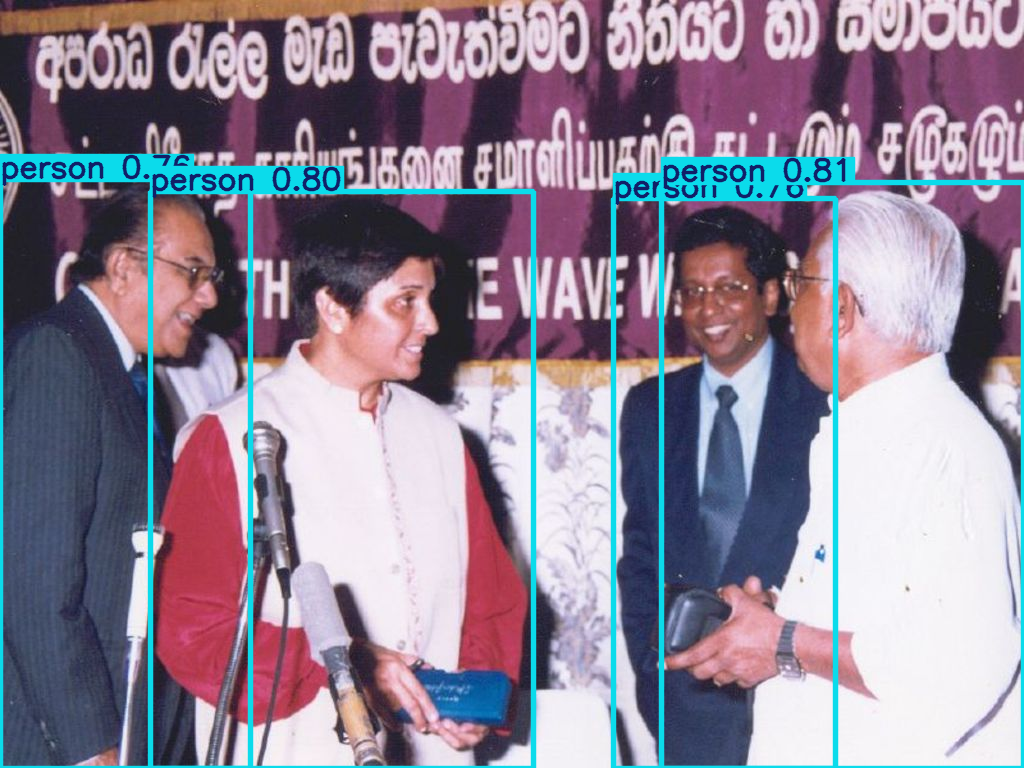

In [24]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train4/weights/best.pt")

results = model("/content/helmet_dataset/images/val", conf=0.5)

results[0].show()



In [26]:
model = YOLO("/content/runs/detect/train4/weights/best.pt")
metrics= model.val(
    data="/content/helmet_dataset/dataset.yaml",
    split="val",
    imgsz=640,
    conf=0.25
)
print (metrics)

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1209.3±1369.7 MB/s, size: 486.2 KB)
val: Scanning /content/helmet_dataset/labels/val.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 349.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 4.4it/s 14.4s
                   all       1000       4203      0.829      0.771      0.838       0.59
                helmet        180        326      0.848       0.82      0.874      0.583
                person        900       3499      0.757      0.666      0.757      0.515
            motorcycle        212        378      0.884      0.826      0.882      0.671
Speed: 1.4ms preprocess, 4.2ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
ultr

Saving test5.jpg to test5.jpg

image 1/1 /content/test5.jpg: 384x640 2 helmets, 1 person, 3 motorcycles, 8.6ms
Speed: 2.2ms preprocess, 8.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


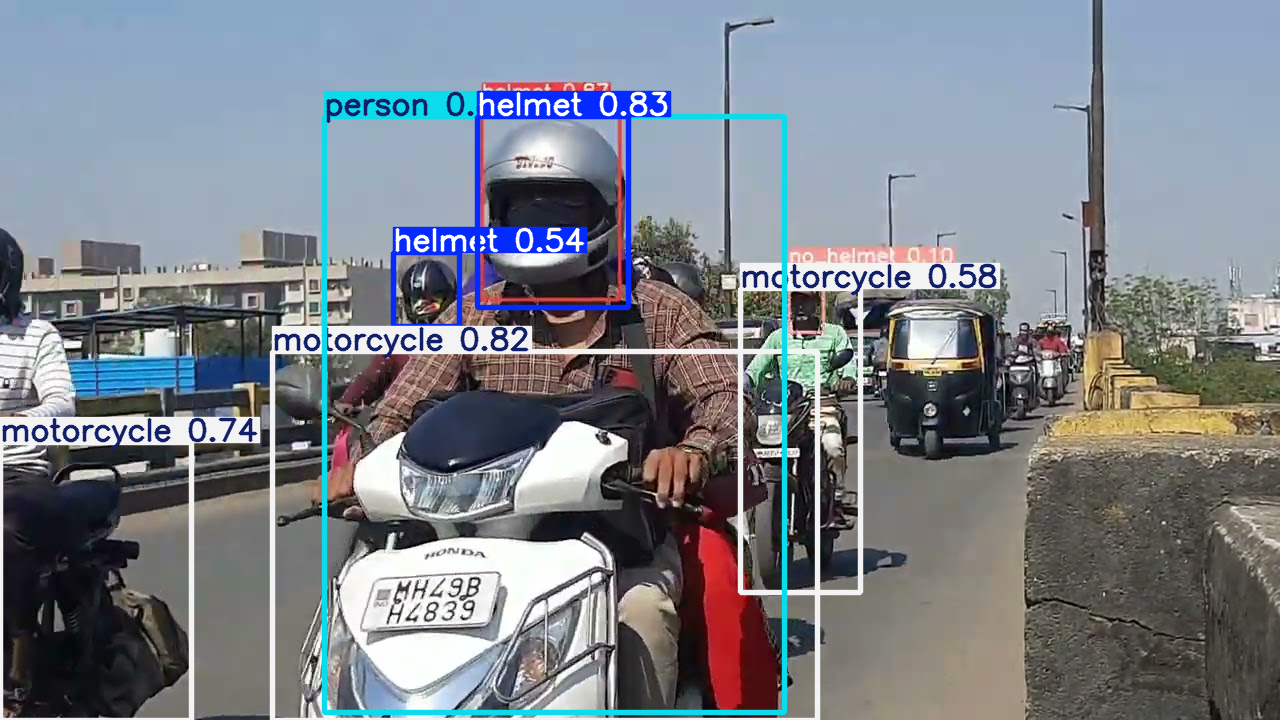

In [34]:
from google.colab import files
uploded= files.upload()
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train4/weights/best.pt")
results= model("/content/test5.jpg", conf=0.5)
results[0].show()

